In [1]:
import pandas as pd
import subprocess
import matplotlib.pyplot as plt

In [2]:
effectidor_output = pd.read_excel("data/effectidor_output.xlsx")

In [3]:
effectidor_output

,bacterial strain,locus,score,annotation,sequence
0,P. fluorescens CREA C16,BJN39_RS03720,1.000000,MaoC family dehydratase,MPYVPVAELKDHVGKELGRSEWLTIDQERINLFAEATGDYQFIHVD...
1,P. fluorescens CREA C16,BJN39_RS22615,1.000000,type III effector 1,MASQQGIVEETASATASTGTVQEVLLRITRWQVLLDKRLSSQMSLL...
2,P. fluorescens CREA C16,BJN39_RS21395,1.000000,HopJ type III effector protein,MTDLNTLRASLNSGDHAFADTLAFIAAGYDYQPQAFTNGGVENAAG...
3,P. fluorescens CREA C16,BJN39_RS19045,1.000000,MBL fold metallo-hydrolase,MRFAVLGSGSQGNGTLIASADTYVLVDCGFSLRETEKRLLRLGVHP...
4,P. fluorescens CREA C16,BJN39_RS20870,1.000000,membrane-targeted effector domain-containing t...,MSTPKAPTAEEIKSDLNQIGDYLFQPSAPLLPENQPSIEQAYLKNL...
...,...,...,...,...,...
1256,P. synxantha R6-28-08,C4K01_RS28150,0.984911,patatin-like phospholipase family protein,MNVSSSVVQSQPLLPQNLDQQVKTPLVKGVGESKVSVFRHGDGRVE...
1257,P. synxantha R6-28-08,C4K01_RS26570,0.976471,lytic murein transglycosylase,MPSSLSRRWHLRQLIAASSLILLVACAEKPTAADAQPLPKLQTAPA...
1258,P. synxantha R6-28-08,C4K01_RS04145,0.960190,RAQPRD family integrative conjugative element ...,LPGLIALFGCGLPVSHATAASASEQANLDVMIRQLNALEDTARRSA...
1259,P. synxantha R6-28-08,C4K01_RS22785,0.440577,type II toxin-antitoxin system VapC family toxin,VTTYMLDTCICSFIMRERPECVLERLALEVARSNRIVISAITYAEM...


In [4]:
database_1 = effectidor_output[effectidor_output["score"] >= 0.6]

In [5]:
len(database_1)

651

In [6]:
database_1.to_excel("data/supplementary_table_2.xlsx", index=False)

In [7]:
database_2 = pd.read_excel("data/database_2.xlsx")

In [8]:
database_2

,Effector ID,Amino Acid Sequence
0,Pae0893_23_AvrA1a_1,MWNVSKSSNNLGAYKLPLEAQTPPEKISPFDAMSAAQPEGKAPHDQ...
1,Pcn3113_AvrB1a_1,MGCVSSKGNPVLSPQASFNDASRTFFRALPGPAARQLQVYDQCLIG...
2,Ppi1704B_AvrB2d_1,MLDFLPHSNTFRFHGKIDGERLPLTWISISSDRHADRTKDPYQRLR...
3,PseHC_1_AvrB2h_1,MPYQQALIGVARWPDSHFNRDDAPHQMEYGQSFYNKSRELGESVAS...
4,Psy0533_AvrE1a_1,MHSSSIHRNTGCIIQPPAPANTNAATDLQQKIEQPKQRSSHSLSSV...
5,Pta6605_AvrE1ai_1,MHQAAISGTWTGIFTVHSSSIHRNTGGIIQPTVPANTNAATDLQQK...
6,PsyCC1524_AvrE1ar_1,MGGGKDYWPVLFDENNPARAVDIGNKRKLTPGLRLGVDATVTGAGS...
7,PpeICMP3706_AvrRpt2a_1,MDRFIQNEGLNKVDLPANNSFSPEQLLALLYRHGPIIFGWQTPSND...
8,PsB48_HopAI1a_1,MRRLNQSEVRANTPTRFAVHHRAPTYDVAQSALGENHGGWTAANHF...
9,PlaICMP3507_HopAI1l_1,MPINRPAFNLKLNTAIAQPTVKKDAGAELRRLNQSEVRANTQTRFA...


In [9]:
def write_fasta(df, path, id_key, seq_key):
    with open(path, "w") as fh:
        for _, row in df.iterrows():
            fh.write(f">{row[id_key]}\n{row[seq_key]}\n")

In [10]:
write_fasta(database_1, "data/database1.fasta", "locus", "sequence")

In [11]:
write_fasta(database_2, "data/database2.fasta", "Effector ID", "Amino Acid Sequence")

In [12]:
def run_blastp(query_fasta, subject_fasta, out_tsv):
    # version blast 2.16.0

    subprocess.run(
        ["makeblastdb", "-in", subject_fasta, "-dbtype", "prot", "-out", "data/db1"],
        check=True, capture_output=True,
    )
    subprocess.run(
        [
            "blastp",
            "-query", query_fasta,
            "-db", "data/db1",
            "-evalue", "1e-5",
            "-outfmt", "6 qseqid sseqid pident length evalue bitscore",
            "-out", out_tsv,
        ],
        check=True, capture_output=True,
    )


In [13]:
run_blastp("data/database2.fasta", "data/database1.fasta", "data/blastp_psy_vs_env_evalue1e-5.tsv")

In [14]:
hit_loci = set()
with open("data/blastp_psy_vs_env_evalue1e-5.tsv") as file:
    for line in file:
        qseqid, sseqid, *_ = line.strip().split("\t")
        hit_loci.add(sseqid)

In [15]:
good = database_1[~database_1["locus"].isin(hit_loci)]
bad = database_1[database_1["locus"].isin(hit_loci)]

In [16]:
print(f"\nRemoved (similar to Psy, e-value <= 1e-5): {len(bad)}")
print(f"Kept (distinct from Psy): {len(good)}")


Removed (similar to Psy, e-value <= 1e-5): 55
Kept (distinct from Psy): 596


In [17]:
good

,bacterial strain,locus,score,annotation,sequence
0,P. fluorescens CREA C16,BJN39_RS03720,1.000000,MaoC family dehydratase,MPYVPVAELKDHVGKELGRSEWLTIDQERINLFAEATGDYQFIHVD...
1,P. fluorescens CREA C16,BJN39_RS22615,1.000000,type III effector 1,MASQQGIVEETASATASTGTVQEVLLRITRWQVLLDKRLSSQMSLL...
2,P. fluorescens CREA C16,BJN39_RS21395,1.000000,HopJ type III effector protein,MTDLNTLRASLNSGDHAFADTLAFIAAGYDYQPQAFTNGGVENAAG...
3,P. fluorescens CREA C16,BJN39_RS19045,1.000000,MBL fold metallo-hydrolase,MRFAVLGSGSQGNGTLIASADTYVLVDCGFSLRETEKRLLRLGVHP...
5,P. fluorescens CREA C16,BJN39_RS12145,1.000000,anti-virulence regulator CigR family protein,MISSRKWIATASSLALVFASAVASADPGNGKGQGNGKGNPQNMQDH...
...,...,...,...,...,...
1253,P. synxantha 30B,C4K03_RS04265,0.925283,RAQPRD family integrative conjugative element ...,IALPGLIVLIGCSLPVSHAAAASASEQANLDVMIRQLNALEDTARR...
1255,P. synxantha R6-28-08,C4K01_RS25040,0.999971,HopJ type III effector protein,MTDLNTLRASLDSGEHVFADTLAFVAANYDYQPQAFTNGDVENAAG...
1256,P. synxantha R6-28-08,C4K01_RS28150,0.984911,patatin-like phospholipase family protein,MNVSSSVVQSQPLLPQNLDQQVKTPLVKGVGESKVSVFRHGDGRVE...
1257,P. synxantha R6-28-08,C4K01_RS26570,0.976471,lytic murein transglycosylase,MPSSLSRRWHLRQLIAASSLILLVACAEKPTAADAQPLPKLQTAPA...


In [18]:
good["annotation"].value_counts()

annotation
hypothetical protein                              72
SpvB/TcaC N-terminal domain-containing protein    51
lytic murein transglycosylase                     50
HopJ type III effector protein                    49
patatin-like phospholipase family protein         39
                                                  ..
AAA domain-containing protein                      1
autotransporter domain-containing protein          1
allophanate hydrolase                              1
DNA-binding domain-containing protein              1
pseudogene N-acetyltransferase                     1
Name: count, Length: 94, dtype: int64

In [19]:
unique_annotations = good[good["annotation"]!="hypothetical protein"]["annotation"].nunique()
print(f"\nUnique effector annotations in final set: {unique_annotations}")


Unique effector annotations in final set: 93


In [20]:
print("Top 15 annotations:")
counts = good[good["annotation"]!="hypothetical protein"]["annotation"].value_counts().reset_index(name="count").head(15)
counts

Top 15 annotations:


,annotation,count
0,SpvB/TcaC N-terminal domain-containing protein,51
1,lytic murein transglycosylase,50
2,HopJ type III effector protein,49
3,patatin-like phospholipase family protein,39
4,MaoC family dehydratase,31
5,shikimate kinase AroK,25
6,GNAT family N-acetyltransferase,24
7,MBL fold metallo-hydrolase,23
8,anti-virulence regulator CigR family protein,23
9,transglycosylase SLT domain-containing protein,15


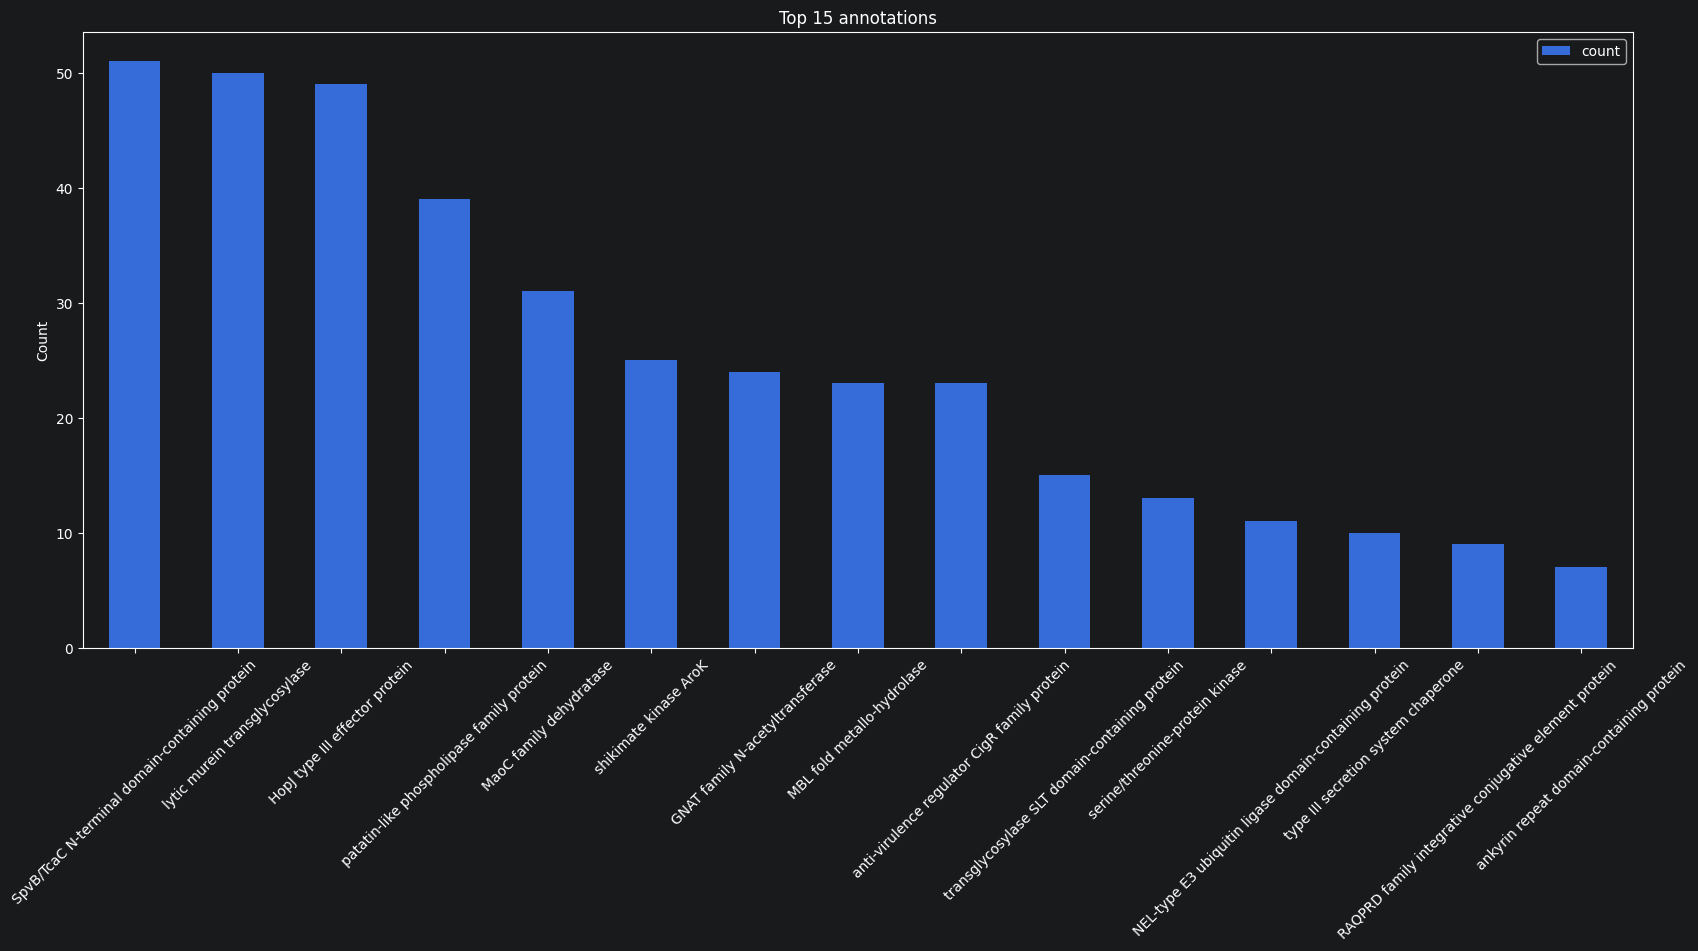

In [21]:
ax = counts.plot(kind="bar", figsize=(20, 8), title= "Top 15 annotations")

ax.set_xticklabels(counts["annotation"], rotation=45)

plt.ylabel("Count")
plt.show()

In [22]:
good["bacterial strain"].value_counts()

bacterial strain
P. ogarae FR1                                     81
P. sp. B21-010                                    69
P. synxantha KENGFT3                              68
P. fluorescens Q8r1-96                            25
P. brassicacearum DF41                            16
P. sp. S1Bt7                                      16
P. sp. S1Bt42                                     16
P. fluorescens FW300-N2E2                         14
P. brassicacearum WCS365                          14
P. thivervalensis SC5                             11
P. synxantha R2-54-08W                            11
P. sp. S1Bt3                                      11
P. bijieensis SP1                                 11
P. synxantha LBUM223                              10
P. rhodesiae AAMF24                               10
P. fluorescens DR133                              10
P. fluorescens CREA C16                           10
P. sp. B21-054                                    10
P. sp. WCS374                

In [23]:
good

,bacterial strain,locus,score,annotation,sequence
0,P. fluorescens CREA C16,BJN39_RS03720,1.000000,MaoC family dehydratase,MPYVPVAELKDHVGKELGRSEWLTIDQERINLFAEATGDYQFIHVD...
1,P. fluorescens CREA C16,BJN39_RS22615,1.000000,type III effector 1,MASQQGIVEETASATASTGTVQEVLLRITRWQVLLDKRLSSQMSLL...
2,P. fluorescens CREA C16,BJN39_RS21395,1.000000,HopJ type III effector protein,MTDLNTLRASLNSGDHAFADTLAFIAAGYDYQPQAFTNGGVENAAG...
3,P. fluorescens CREA C16,BJN39_RS19045,1.000000,MBL fold metallo-hydrolase,MRFAVLGSGSQGNGTLIASADTYVLVDCGFSLRETEKRLLRLGVHP...
5,P. fluorescens CREA C16,BJN39_RS12145,1.000000,anti-virulence regulator CigR family protein,MISSRKWIATASSLALVFASAVASADPGNGKGQGNGKGNPQNMQDH...
...,...,...,...,...,...
1253,P. synxantha 30B,C4K03_RS04265,0.925283,RAQPRD family integrative conjugative element ...,IALPGLIVLIGCSLPVSHAAAASASEQANLDVMIRQLNALEDTARR...
1255,P. synxantha R6-28-08,C4K01_RS25040,0.999971,HopJ type III effector protein,MTDLNTLRASLDSGEHVFADTLAFVAANYDYQPQAFTNGDVENAAG...
1256,P. synxantha R6-28-08,C4K01_RS28150,0.984911,patatin-like phospholipase family protein,MNVSSSVVQSQPLLPQNLDQQVKTPLVKGVGESKVSVFRHGDGRVE...
1257,P. synxantha R6-28-08,C4K01_RS26570,0.976471,lytic murein transglycosylase,MPSSLSRRWHLRQLIAASSLILLVACAEKPTAADAQPLPKLQTAPA...


In [24]:
good.to_excel("data/supplementary_table_4.xlsx", index=False)